# Mediterranean GBD Disease Burden Transition
### Comparative analysis of disease burden shift in Tunisia and Mediterranean neighbors


Global Burden of Disease (GBD) is a comprehensive epidemiological study conducted by the Institute for Health Metrics and Evaluation (IHME) that quantifies mortality and morbidity from diseases, injuries, and risk factors across countries and time periods.
The GBD relies on two key metrics:
DALYs (Disability-Adjusted Life Years) represent the disease burden metric used throughout this analysis. One DALY equals one year of lost healthy life. DALYs are calculated as the sum of two components:

YLL (Years of Life Lost) — premature mortality due to a disease

YLD (Years Lived with Disability) — years lived in a state of reduced health due to a disease or injury

By combining mortality and morbidity into a single metric, DALYs allow for direct comparison of disease burden across different causes and populations.
HALE (Healthy Life Expectancy) is a complementary metric representing the expected number of years a person can live in full health, accounting for both mortality and disability.

### Research Question

This project investigates whether Tunisia—a middle-income Mediterranean country in North Africa—is undergoing an epidemiological transition from infectious disease dominance toward chronic disease dominance. Specifically, we examine whether this transition is evident in Tunisia's disease burden over the past three decades (1990–2023), and compare Tunisia's trajectory to its Mediterranean neighbors and to Italy, a high-income European country that has already completed this transition. This comparison allows us to identify patterns of disease burden shift and hypothesize factors driving the transition at different stages of economic development.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import PercentFormatter


## Section 1: Exploratory data analysis  
In this section, the GBD dataset is loaded and basic checks are performed to verify the data was loaded correctly.  
Some typical verification include:  
-Checking the shape of the dataset: if the numbers of columns and columns load correctly  
-Checking the column names of the dataset   
-Information section to check datatypes and null values  
-Checking unique values in key columns of the dataset   

In [2]:
#reading the gbd csv data file
gbd_df = pd.read_csv("../data/gbd-data.csv")
gbd_df.head()

,population_group_id,population_group_name,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
0,1,All Population,2,DALYs (Disability-Adjusted Life Years),141,Egypt,3,Both,22,All ages,491,Cardiovascular diseases,2,Percent,1990,0.175735,0.204860,0.152183
1,1,All Population,2,DALYs (Disability-Adjusted Life Years),154,Tunisia,3,Both,22,All ages,974,Diabetes and kidney diseases,2,Percent,1990,0.038285,0.046878,0.030722
2,1,All Population,2,DALYs (Disability-Adjusted Life Years),86,Italy,3,Both,22,All ages,491,Cardiovascular diseases,2,Percent,1991,0.219402,0.239270,0.198262
3,1,All Population,2,DALYs (Disability-Adjusted Life Years),86,Italy,3,Both,22,All ages,491,Cardiovascular diseases,2,Percent,1990,0.219066,0.239085,0.198096
4,1,All Population,2,DALYs (Disability-Adjusted Life Years),86,Italy,3,Both,22,All ages,974,Diabetes and kidney diseases,2,Percent,1991,0.038860,0.041750,0.036021


In [3]:
#checking the shape (rowsxcols) of data
gbd_df.shape 

(680, 18)

In [4]:
#checking column names of the csv data
gbd_df.columns

Index(['population_group_id', 'population_group_name', 'measure_id',
       'measure_name', 'location_id', 'location_name', 'sex_id', 'sex_name',
       'age_id', 'age_name', 'cause_id', 'cause_name', 'metric_id',
       'metric_name', 'year', 'val', 'upper', 'lower'],
      dtype='str')

In [5]:
#checking information
gbd_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 680 entries, 0 to 679
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   population_group_id    680 non-null    int64  
 1   population_group_name  680 non-null    str    
 2   measure_id             680 non-null    int64  
 3   measure_name           680 non-null    str    
 4   location_id            680 non-null    int64  
 5   location_name          680 non-null    str    
 6   sex_id                 680 non-null    int64  
 7   sex_name               680 non-null    str    
 8   age_id                 680 non-null    int64  
 9   age_name               680 non-null    str    
 10  cause_id               680 non-null    int64  
 11  cause_name             680 non-null    str    
 12  metric_id              680 non-null    int64  
 13  metric_name            680 non-null    str    
 14  year                   680 non-null    int64  
 15  val              

In [6]:
#checking unique values in cause_name to get exact strings for filtering
display(gbd_df["cause_name"].unique())

#checking unique values in location_name to get exact strings for filtering
display(gbd_df["location_name"].unique())

<StringArray>
[                'Cardiovascular diseases',
            'Diabetes and kidney diseases',
 'Alzheimer's disease and other dementias',
 'Respiratory infections and tuberculosis',
               'Other infectious diseases']
Length: 5, dtype: str

<StringArray>
['Egypt', 'Tunisia', 'Italy', 'Morocco']
Length: 4, dtype: str

## Section 2: Visualisation  
This section starts by analyzing the changes of the different chronic and infectious diseases across the years in Tunisia.

In [7]:
#creating Tunisia dataframe
tunisia_df = gbd_df[gbd_df["location_name"]== "Tunisia"].copy()
tunisia_df.head()

,population_group_id,population_group_name,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
1,1,All Population,2,DALYs (Disability-Adjusted Life Years),154,Tunisia,3,Both,22,All ages,974,Diabetes and kidney diseases,2,Percent,1990,0.038285,0.046878,0.030722
10,1,All Population,2,DALYs (Disability-Adjusted Life Years),154,Tunisia,3,Both,22,All ages,543,Alzheimer's disease and other dementias,2,Percent,1990,0.007006,0.016110,0.002835
12,1,All Population,2,DALYs (Disability-Adjusted Life Years),154,Tunisia,3,Both,22,All ages,956,Respiratory infections and tuberculosis,2,Percent,1990,0.103092,0.127806,0.082952
13,1,All Population,2,DALYs (Disability-Adjusted Life Years),154,Tunisia,3,Both,22,All ages,961,Other infectious diseases,2,Percent,1990,0.032181,0.043588,0.022986
16,1,All Population,2,DALYs (Disability-Adjusted Life Years),154,Tunisia,3,Both,22,All ages,491,Cardiovascular diseases,2,Percent,1990,0.090403,0.111139,0.068657


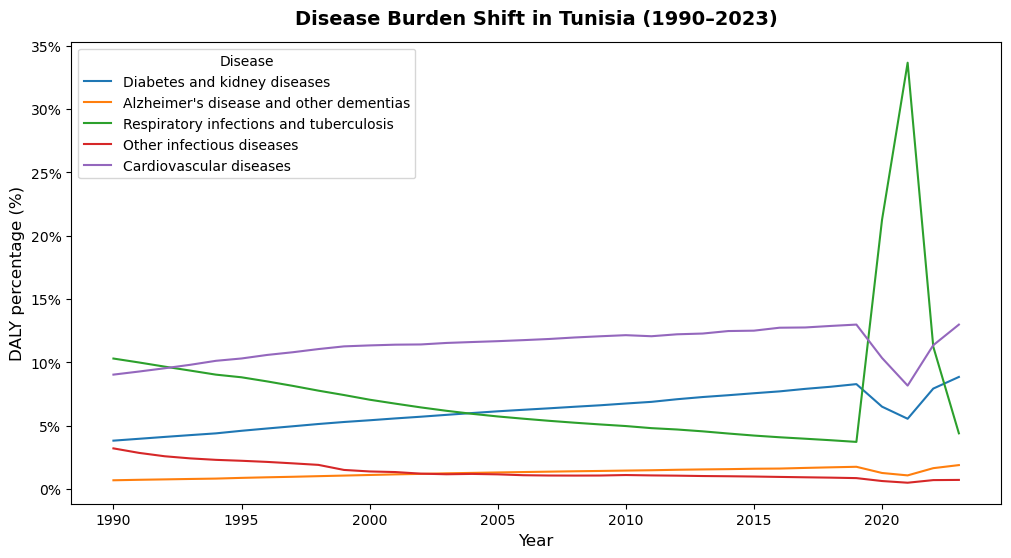

In [ ]:

#setting dimesnions of the plot
plt.figure(figsize = (12, 6))

#drawing the plot
tn_plot= sns.lineplot(
    data= tunisia_df,
    x = "year", 
    y="val", 
    hue= "cause_name")
b
#title of the figure 
tn_plot.set_title("Disease Burden Shift in Tunisia (1990–2023)",fontsize= 14, fontweight= "bold", y=1.02)

#set label for x axis
tn_plot.set_xlabel("Year", size= 12)

#set label for y axis
tn_plot.set_ylabel("DALY percentage (%)", size = 12)
tn_plot.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals= 0))
#set label for the hue
plt.legend(title = "Disease", loc= "upper left")

plt.savefig("../figures/Disease_Burden_Shift_Tunisia.png")
plt.show()


### Interpretation  
The DALY percentage of Alzheimer´s disease and other dementias remain relatively constant and below 3% over the years suggesting a limited and relatively stable burden on the Tunisian population.   
Respiratory infections and tuberculosis interestingly started with a higher DALY percentage of 11% compared to all other diseases in 1990 to then decline up until 2019 to roughly 4-5%. Around 2020 a striking spike reaching 33% is noticed,suggesting respiratory infections had a high impact on Tunisian population, most likely due to COVID-19, which primarily affects the respiratory system, before declining again to 4-5% in 2023.
Cardiovascular disease DALY percentage increased gradually from roughly 9% in 1990 to 13% in 2023. Diabetes and kidney diseases show a pattern similar to cardiovascular diseases. 
This observed increase might be consistent with the epidemiological transition from infectious to chronic disease burden.  
Furthermore, both chronic diseases show a brief dip  around 2020. This simultaneous dip in cardiovascular and diabetes raises an interesting question: If confinement increased respiratory disease exposure, why did it not increase chronic disease burden?  This may suggest the cause might be disruptions in disease reporting in healthcare during the COVID-19 pandemic rather than a reduction in burden.  




This section focuses on cardiovascular and respiratory disease burden differences over time in a European mediterranean country like Italy and mediterranean North african countries like Morocco, Egypt and Tunisia.

This comparison aims to investigate whether a significant burden shift in chronic diseases occurs over time within North African countries, specifically evaluating their trajectory in relation to Italy. Furthermore, this analysis looks at relative burden shift between chronic and respiratory diseases over time.

In [9]:
#creating dataframe for cardiovascular diseasesfor all countries
cvdis_df = gbd_df[gbd_df["cause_name"]=="Cardiovascular diseases"].copy()
cvdis_df.head()

,population_group_id,population_group_name,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
0,1,All Population,2,DALYs (Disability-Adjusted Life Years),141,Egypt,3,Both,22,All ages,491,Cardiovascular diseases,2,Percent,1990,0.175735,0.204860,0.152183
2,1,All Population,2,DALYs (Disability-Adjusted Life Years),86,Italy,3,Both,22,All ages,491,Cardiovascular diseases,2,Percent,1991,0.219402,0.239270,0.198262
3,1,All Population,2,DALYs (Disability-Adjusted Life Years),86,Italy,3,Both,22,All ages,491,Cardiovascular diseases,2,Percent,1990,0.219066,0.239085,0.198096
6,1,All Population,2,DALYs (Disability-Adjusted Life Years),148,Morocco,3,Both,22,All ages,491,Cardiovascular diseases,2,Percent,1993,0.199305,0.224421,0.171086
16,1,All Population,2,DALYs (Disability-Adjusted Life Years),154,Tunisia,3,Both,22,All ages,491,Cardiovascular diseases,2,Percent,1990,0.090403,0.111139,0.068657


In [10]:
#creating dataframe for respiratory diseases for all countries
respinf_df = gbd_df[gbd_df["cause_name"]=="Respiratory infections and tuberculosis"].copy()
respinf_df.head()

,population_group_id,population_group_name,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
8,1,All Population,2,DALYs (Disability-Adjusted Life Years),141,Egypt,3,Both,22,All ages,956,Respiratory infections and tuberculosis,2,Percent,1990,0.154781,0.183510,0.130223
12,1,All Population,2,DALYs (Disability-Adjusted Life Years),154,Tunisia,3,Both,22,All ages,956,Respiratory infections and tuberculosis,2,Percent,1990,0.103092,0.127806,0.082952
20,1,All Population,2,DALYs (Disability-Adjusted Life Years),154,Tunisia,3,Both,22,All ages,956,Respiratory infections and tuberculosis,2,Percent,1993,0.093586,0.115078,0.073845
26,1,All Population,2,DALYs (Disability-Adjusted Life Years),148,Morocco,3,Both,22,All ages,956,Respiratory infections and tuberculosis,2,Percent,1990,0.090004,0.118956,0.068535
30,1,All Population,2,DALYs (Disability-Adjusted Life Years),86,Italy,3,Both,22,All ages,956,Respiratory infections and tuberculosis,2,Percent,1990,0.011585,0.012616,0.010317


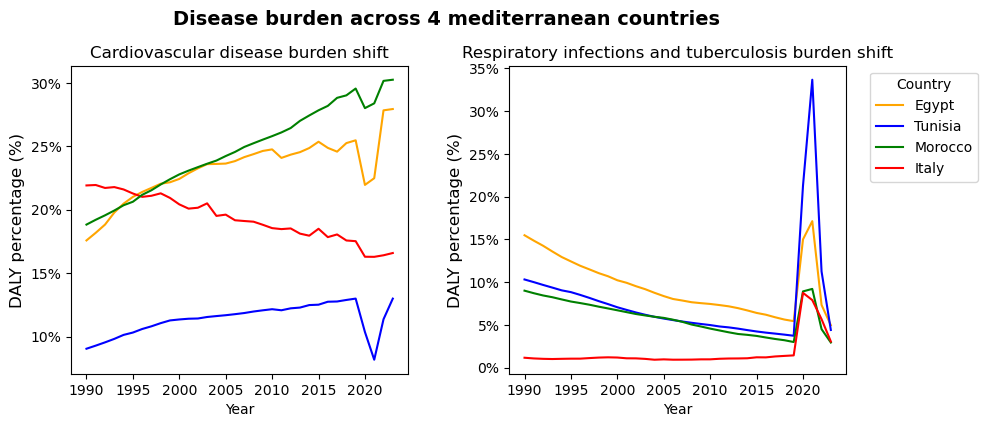

In [11]:
#creating a color palette for each country
palette={"Tunisia":"blue",
         "Egypt":"orange",
         "Morocco":"green",
         "Italy":"red"}
#creating figure with subplots
fig, axes = plt.subplots(1,2, figsize = (10, 4), sharex=True)

#title of the figure 
plt.suptitle("Disease burden across 4 mediterranean countries",fontsize= 14, fontweight= "bold", y=1.02)

cv_plot=sns.lineplot(
    data = cvdis_df,
    x= "year",
    y= "val",
    ax=axes[0],
    palette=palette,
    hue= "location_name")
axes[0].set_title("Cardiovascular disease burden shift")

resp_plot=sns.lineplot(
    data = respinf_df,
    x= "year",
    y= "val",
    ax = axes[1],
    palette=palette,
    hue= "location_name")
axes[1].set_title("Respiratory infections and tuberculosis burden shift")

#set label for both y axis and x axis
for ax in axes:
    ax.set_xlabel("Year")
    ax.set_ylabel("DALY percentage (%)", size = 12)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals= 0))

#set label for the hue
axes[0].get_legend().remove()
axes[1].get_legend().remove()
plt.legend(title = "Country", loc= "upper left", bbox_to_anchor=(1.05,1))


plt.subplots_adjust(wspace= 0.3)
plt.savefig("../figures/Disease_burden_across_4_mediterranean_countries.png", bbox_inches= "tight")

plt.show()


This section investigates further the difference in diseases burden of 2 mediterranean countries shown in Figure 2 focusing solely on cardiovascular disease and respiratory infections burden shift of Tunisia and Italy and their confidence intervals to assess whether the observed burden shift remains consistent when accounting for estimate uncertainty.

In [12]:
#creating dataframe for italy and Tunisia only
cv1_df= cvdis_df[cvdis_df["location_name"].isin(["Tunisia","Italy"])].copy()
cv1_df.head()

,population_group_id,population_group_name,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
2,1,All Population,2,DALYs (Disability-Adjusted Life Years),86,Italy,3,Both,22,All ages,491,Cardiovascular diseases,2,Percent,1991,0.219402,0.239270,0.198262
3,1,All Population,2,DALYs (Disability-Adjusted Life Years),86,Italy,3,Both,22,All ages,491,Cardiovascular diseases,2,Percent,1990,0.219066,0.239085,0.198096
16,1,All Population,2,DALYs (Disability-Adjusted Life Years),154,Tunisia,3,Both,22,All ages,491,Cardiovascular diseases,2,Percent,1990,0.090403,0.111139,0.068657
29,1,All Population,2,DALYs (Disability-Adjusted Life Years),86,Italy,3,Both,22,All ages,491,Cardiovascular diseases,2,Percent,1993,0.217760,0.237185,0.196428
37,1,All Population,2,DALYs (Disability-Adjusted Life Years),154,Tunisia,3,Both,22,All ages,491,Cardiovascular diseases,2,Percent,1991,0.092841,0.113363,0.070985


In [13]:
#creating dataframe for italy and Tunisia only
respinf2_df= respinf_df[respinf_df["location_name"].isin(["Tunisia","Italy"])].copy()
respinf2_df.head()

,population_group_id,population_group_name,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
12,1,All Population,2,DALYs (Disability-Adjusted Life Years),154,Tunisia,3,Both,22,All ages,956,Respiratory infections and tuberculosis,2,Percent,1990,0.103092,0.127806,0.082952
20,1,All Population,2,DALYs (Disability-Adjusted Life Years),154,Tunisia,3,Both,22,All ages,956,Respiratory infections and tuberculosis,2,Percent,1993,0.093586,0.115078,0.073845
30,1,All Population,2,DALYs (Disability-Adjusted Life Years),86,Italy,3,Both,22,All ages,956,Respiratory infections and tuberculosis,2,Percent,1990,0.011585,0.012616,0.010317
33,1,All Population,2,DALYs (Disability-Adjusted Life Years),154,Tunisia,3,Both,22,All ages,956,Respiratory infections and tuberculosis,2,Percent,1991,0.099985,0.124813,0.079804
57,1,All Population,2,DALYs (Disability-Adjusted Life Years),86,Italy,3,Both,22,All ages,956,Respiratory infections and tuberculosis,2,Percent,1991,0.010783,0.011744,0.009558


In [14]:
#filtering the cv1 dataframe to specific year
cv_years_df= cv1_df[cv1_df["year"].isin([1990,1995, 2000, 2005, 2010, 2015, 2019, 2023])]
cv_years_df.head()


,population_group_id,population_group_name,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
3,1,All Population,2,DALYs (Disability-Adjusted Life Years),86,Italy,3,Both,22,All ages,491,Cardiovascular diseases,2,Percent,1990,0.219066,0.239085,0.198096
16,1,All Population,2,DALYs (Disability-Adjusted Life Years),154,Tunisia,3,Both,22,All ages,491,Cardiovascular diseases,2,Percent,1990,0.090403,0.111139,0.068657
92,1,All Population,2,DALYs (Disability-Adjusted Life Years),86,Italy,3,Both,22,All ages,491,Cardiovascular diseases,2,Percent,1995,0.212717,0.233069,0.191263
106,1,All Population,2,DALYs (Disability-Adjusted Life Years),154,Tunisia,3,Both,22,All ages,491,Cardiovascular diseases,2,Percent,1995,0.103143,0.126599,0.080306
134,1,All Population,2,DALYs (Disability-Adjusted Life Years),86,Italy,3,Both,22,All ages,491,Cardiovascular diseases,2,Percent,2000,0.204144,0.225597,0.180825


In [15]:


#same thing for respinf2 df
resp_years_df = respinf2_df[respinf2_df["year"].isin([1990,1995, 2000, 2005, 2010, 2015, 2019, 2023])]
resp_years_df.head()


,population_group_id,population_group_name,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
12,1,All Population,2,DALYs (Disability-Adjusted Life Years),154,Tunisia,3,Both,22,All ages,956,Respiratory infections and tuberculosis,2,Percent,1990,0.103092,0.127806,0.082952
30,1,All Population,2,DALYs (Disability-Adjusted Life Years),86,Italy,3,Both,22,All ages,956,Respiratory infections and tuberculosis,2,Percent,1990,0.011585,0.012616,0.010317
112,1,All Population,2,DALYs (Disability-Adjusted Life Years),86,Italy,3,Both,22,All ages,956,Respiratory infections and tuberculosis,2,Percent,1995,0.010509,0.011604,0.009350
162,1,All Population,2,DALYs (Disability-Adjusted Life Years),154,Tunisia,3,Both,22,All ages,956,Respiratory infections and tuberculosis,2,Percent,2000,0.070603,0.083404,0.057726
215,1,All Population,2,DALYs (Disability-Adjusted Life Years),154,Tunisia,3,Both,22,All ages,956,Respiratory infections and tuberculosis,2,Percent,1995,0.088293,0.107127,0.070410


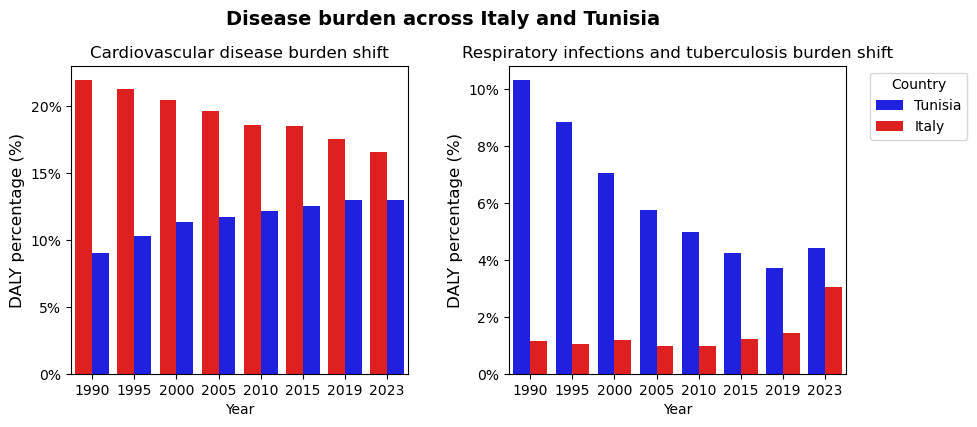

In [16]:
#creating a color palette for each country
palette={"Tunisia":"blue",
         "Italy":"red"}

#calculating the errors for barplot
upper_error = cv_years_df["upper"] - cv_years_df["val"]
lower_error = cv_years_df["val"] - cv_years_df["lower"]

#creating figure with subplots
fig, axes = plt.subplots(1,2, figsize = (10, 4), sharex=True)

#title of the figure 
plt.suptitle("Disease burden across Italy and Tunisia ",fontsize= 14, fontweight= "bold", y=1.02)

cv2_plot=sns.barplot(
    data = cv_years_df,
    x= "year",
    y= "val",
    ax=axes[0],
    palette=palette,
    hue= "location_name")
axes[0].set_title("Cardiovascular disease burden shift")

resp2_plot=sns.barplot(
    data = resp_years_df ,
    x= "year",
    y= "val",
    ax = axes[1],
    palette=palette,
    hue= "location_name")

axes[1].set_title("Respiratory infections and tuberculosis burden shift")

#set label for both y axis and x axis
for ax in axes:
    ax.set_xlabel("Year")
    ax.set_ylabel("DALY percentage (%)", size = 12)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals= 0))

#set label for the hue
axes[0].get_legend().remove()
axes[1].get_legend().remove()
plt.legend(title = "Country", loc= "upper left", bbox_to_anchor=(1.05,1))


plt.subplots_adjust(wspace= 0.3)
plt.savefig("../figures/Disease_burden_transition_overview.png", bbox_inches= "tight")

plt.show()

